In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
# Upload Dataset

from google.colab import files
uploaded = files.upload()

Saving feature-engineered-data.csv to feature-engineered-data.csv


In [4]:
# Separate Features and Target

df = pd.read_csv('feature-engineered-data.csv')
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [6]:
# Upload and Load Trained Models

uploaded = files.upload()

Saving decision_tree.pkl to decision_tree (1).pkl
Saving lightgbm.pkl to lightgbm.pkl
Saving random_forest.pkl to random_forest.pkl
Saving xgboost.pkl to xgboost.pkl
Saving logistic_regression.pkl to logistic_regression.pkl


In [7]:
log_model = joblib.load("logistic_regression.pkl")
rf_model = joblib.load("random_forest.pkl")
xgb_model = joblib.load("xgboost.pkl")
dt_model = joblib.load("decision_tree.pkl")
lgbm_model = joblib.load("lightgbm.pkl")

In [8]:
# Random Forest Feature Importance

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})
rf_importance = rf_importance.sort_values(by="Importance", ascending=False)
rf_importance.head(15)

,Feature,Importance
49,OverTime_Yes,0.110050
15,StockOptionLevel,0.050714
7,JobLevel,0.040246
22,YearsWithCurrManager,0.037831
9,MonthlyIncome,0.037657
0,Age,0.035760
4,EnvironmentSatisfaction,0.034619
11,NumCompaniesWorked,0.033053
8,JobSatisfaction,0.031980
24,PromotionGap,0.031068


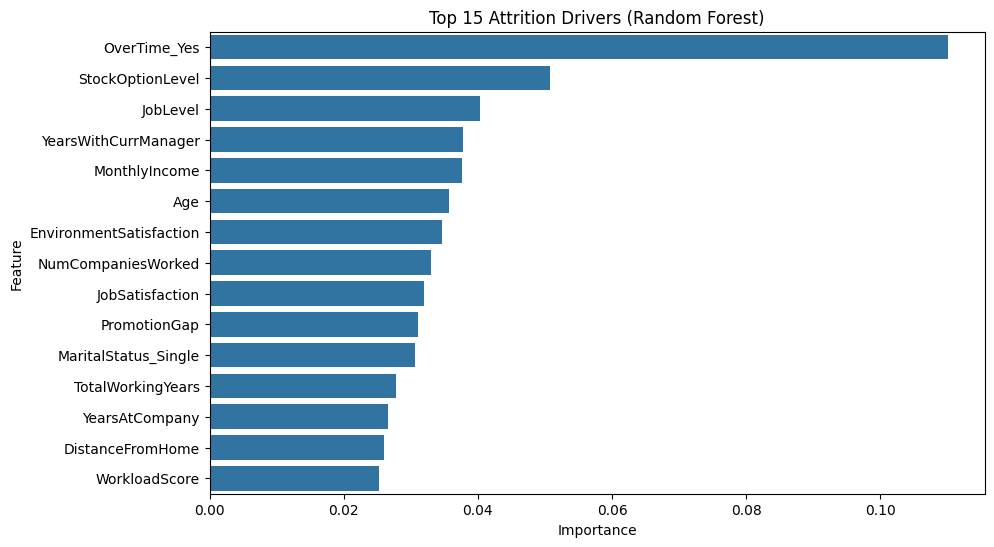

In [10]:
# Visualize Random Forest Drivers

plt.figure(figsize=(10,6))
sns.barplot(
    data=rf_importance.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Attrition Drivers (Random Forest)")
plt.show()

In [9]:
# XGBoost Feature Importance

xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})
xgb_importance = xgb_importance.sort_values(by="Importance", ascending=False)
xgb_importance.head(15)

,Feature,Importance
49,OverTime_Yes,0.160407
7,JobLevel,0.083946
15,StockOptionLevel,0.059876
16,TotalWorkingYears,0.054598
39,JobRole_Human Resources,0.040293
43,JobRole_Research Director,0.030192
44,JobRole_Research Scientist,0.029555
22,YearsWithCurrManager,0.028645
8,JobSatisfaction,0.025125
11,NumCompaniesWorked,0.023070


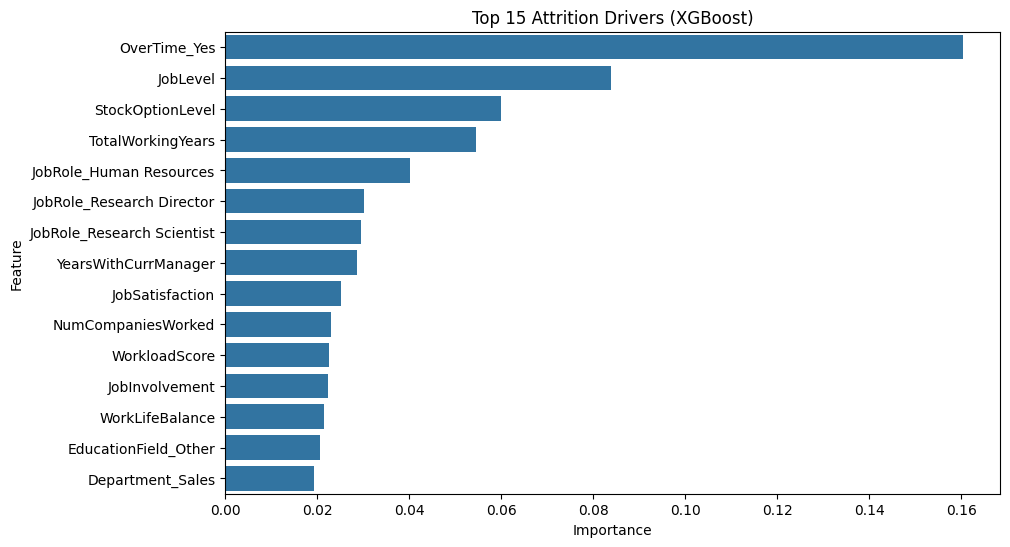

In [11]:
# Visualize XGBoost Drivers

plt.figure(figsize=(10,6))
sns.barplot(
    data=xgb_importance.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Attrition Drivers (XGBoost)")
plt.show()

In [12]:
# LightGBM Feature Importance

lgbm_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgbm_model.feature_importances_
})
lgbm_importance = lgbm_importance.sort_values(
    by="Importance",
    ascending=False
)
lgbm_importance.head(15)

,Feature,Importance
9,MonthlyIncome,374
0,Age,338
1,DailyRate,328
2,DistanceFromHome,273
5,HourlyRate,259
10,MonthlyRate,234
25,CompanyExperienceRatio,234
11,NumCompaniesWorked,224
23,IncomePerYear,219
49,OverTime_Yes,207


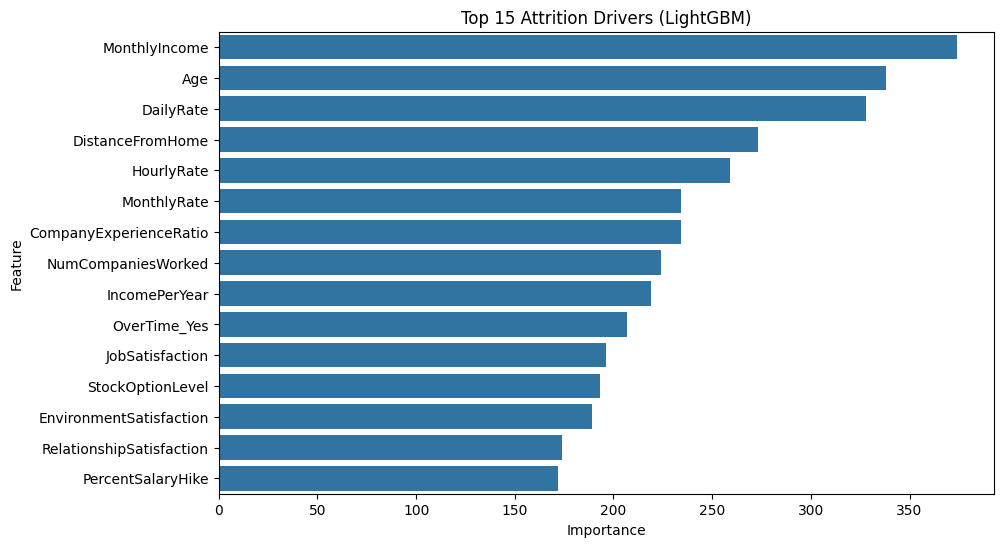

In [13]:
# Visualize LightGBM Drivers

plt.figure(figsize=(10,6))
sns.barplot(
    data=lgbm_importance.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Attrition Drivers (LightGBM)")
plt.show()

In [14]:
# Logistic Regression Coefficient Analysis

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})
coef_df["Absolute"] = abs(coef_df["Coefficient"])
coef_df = coef_df.sort_values(
    by="Absolute",
    ascending=False
)
coef_df.head(15)

,Feature,Coefficient,Absolute
31,Department_Research & Development,1.509730,1.509730
32,Department_Sales,1.381909,1.381909
33,EducationField_Life Sciences,-0.984082,0.984082
49,OverTime_Yes,0.959245,0.959245
29,BusinessTravel_Travel_Frequently,0.931976,0.931976
35,EducationField_Medical,-0.859431,0.859431
40,JobRole_Laboratory Technician,0.810599,0.810599
36,EducationField_Other,-0.738183,0.738183
39,JobRole_Human Resources,0.721530,0.721530
30,BusinessTravel_Travel_Rarely,0.716895,0.716895


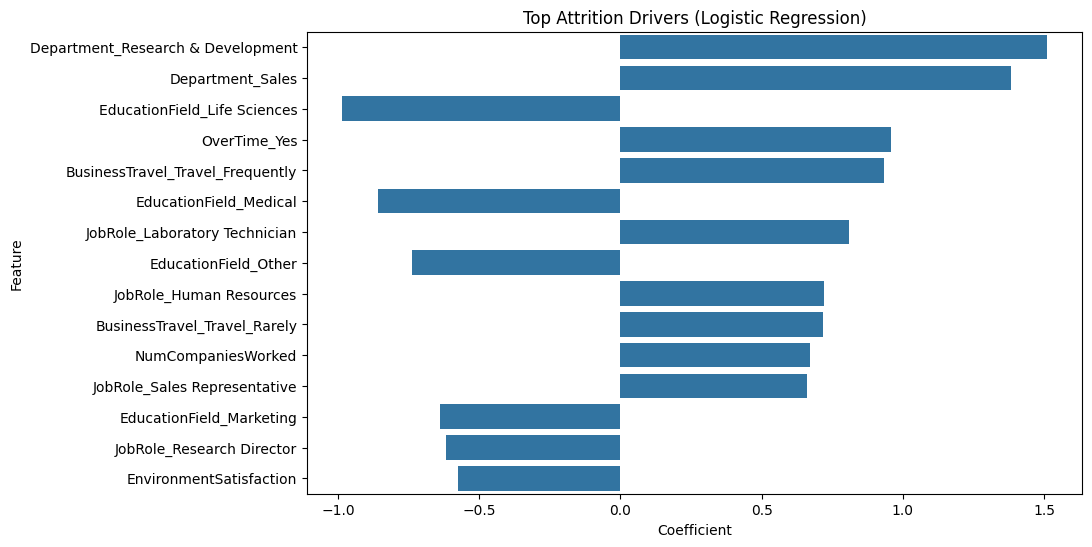

In [15]:
# Visualize Logistic Regression Drivers

plt.figure(figsize=(10,6))
sns.barplot(
    data=coef_df.head(15),
    x="Coefficient",
    y="Feature"
)
plt.title("Top Attrition Drivers (Logistic Regression)")
plt.show()

In [16]:
# Correlation with Attrition

corr = df.corr()
attrition_corr = corr["Attrition"].sort_values(
    ascending=False
)
attrition_corr.head(15)

,Attrition
Attrition,1.000000
OverTime_Yes,0.246118
MaritalStatus_Single,0.175419
JobRole_Sales Representative,0.157234
BusinessTravel_Travel_Frequently,0.115143
JobRole_Laboratory Technician,0.098290
IncomePerYear,0.097731
Department_Sales,0.080855
DistanceFromHome,0.077924
EducationField_Technical Degree,0.069355


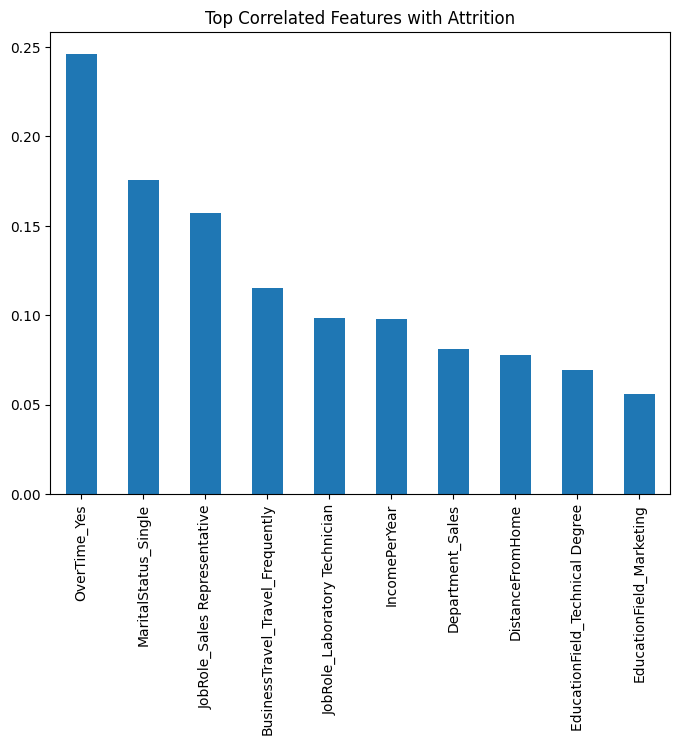

In [17]:
# Visualize Correlation

plt.figure(figsize=(8,6))
attrition_corr.drop("Attrition").head(10).plot(
    kind="bar"
)
plt.title("Top Correlated Features with Attrition")
plt.show()

In [18]:
# Combined Feature Importance (Cross-Model)

importance_df = rf_importance.merge(
    xgb_importance,
    on="Feature",
    suffixes=("_RF","_XGB"))
importance_df = importance_df.merge(
    lgbm_importance,
    on="Feature")
importance_df.rename(
    columns={"Importance":"Importance_LGBM"},
    inplace=True)
importance_df["AverageImportance"] = importance_df[
    ["Importance_RF","Importance_XGB","Importance_LGBM"]
].mean(axis=1)
importance_df = importance_df.sort_values(
    by="AverageImportance",
    ascending=False)
importance_df.head(15)

,Feature,Importance_RF,Importance_XGB,Importance_LGBM,AverageImportance
4,MonthlyIncome,0.037657,0.009046,374,124.682235
5,Age,0.035760,0.015359,338,112.683706
17,DailyRate,0.021723,0.008867,328,109.343530
13,DistanceFromHome,0.026034,0.009938,273,91.011991
22,HourlyRate,0.019645,0.005654,259,86.341766
15,CompanyExperienceRatio,0.023692,0.007801,234,78.010498
26,MonthlyRate,0.018334,0.006121,234,78.008152
7,NumCompaniesWorked,0.033053,0.023070,224,74.685374
18,IncomePerYear,0.021652,0.006390,219,73.009347
0,OverTime_Yes,0.110050,0.160407,207,69.090152


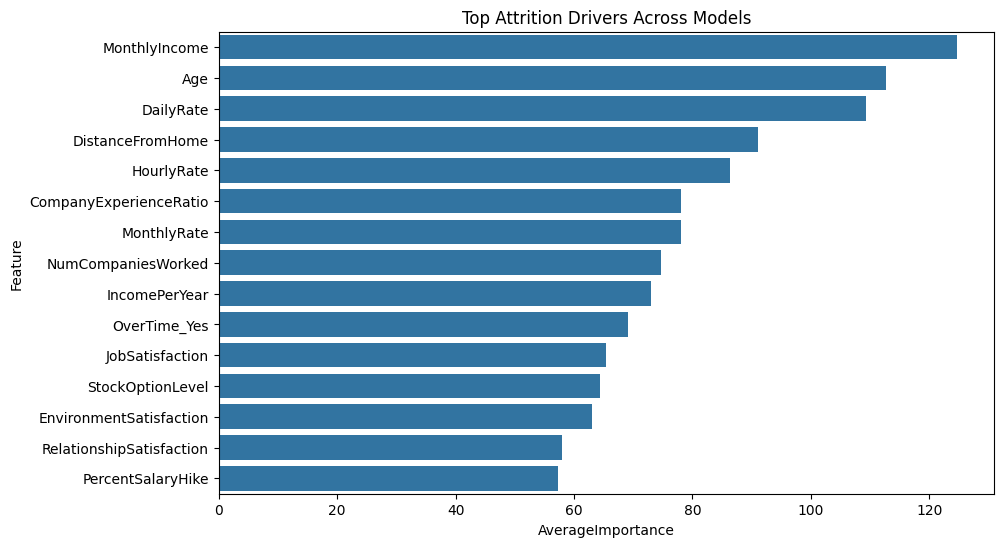

In [19]:
# Visualize Combined Drivers

plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df.head(15),
    x="AverageImportance",
    y="Feature"
)
plt.title("Top Attrition Drivers Across Models")
plt.show()

In [20]:
# Save Driver Analysis

importance_df.to_csv("attrition_drivers_analysis.csv",index=False)